# Log Odds Ratio Test Plots

Generates log odds ratio test plots found in [Fig. 5](figures/figure_5) and the [Supplementary Figures](figures/supplementary)

## Notebook Workflow

1. Load stage-05 odds-ratio result pickle files.
2. Generate the main odds-ratio distribution and summary plots.
3. Produce supplementary variants used in figure panels.
4. Save final figure outputs with publication settings.

In [1]:
import sys
import os
import numpy as np


# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

%load_ext autoreload
%autoreload 2

import importlib
import odds_ratio_test as ort
import odds_ratio_test_plotting as ortplot

print("odds_ratio_test:", ort.__file__)
print("odds_ratio_test_plotting:", ortplot.__file__)

importlib.reload(ortplot)
importlib.reload(ort)

figure5 = os.path.join(repo_root, "figures", "figure_5")
supp = os.path.join(repo_root, "figures", "supplementary")


Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
odds_ratio_test: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup/odds_ratio_test.py
odds_ratio_test_plotting: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup/odds_ratio_test_plotting.py


/Users/calvin/anaconda3/envs/orb-selection/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load bootstrap results - main version (including all orb-weavers)

In [2]:
%autoreload 2
ort_dir = os.path.join(repo_root, "results/odds_ratio_test/Results_Apr14/Run1_occ_30-95_10000x_all_orb")

results = ort.PermulationTestResults.load_from_pickle(f'{ort_dir}/results.pkl')

In [3]:
results.loss_ci_av

array([-2.84580953,  2.83430826])

In [4]:
results.dup_ci_av

array([-2.16984876,  2.17796818])

(<Figure size 600x500 with 1 Axes>,
 <Axes: xlabel='Log odds ratio', ylabel='Density'>)

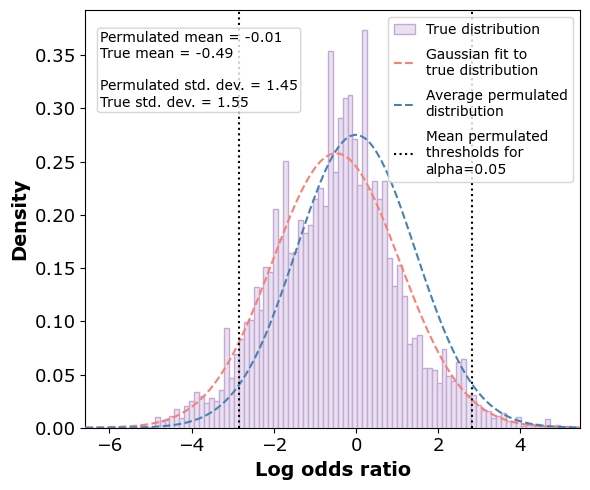

In [5]:
%autoreload 2
ortplot.plot_permulation_results(
    results,
    "loss",
    fg_name="orbweavers",
    bg_name="non-orbweavers",
    gaussfit_color="salmon",
    avpermulation_color="steelblue",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    thresholds_color="black",
    title=False,
    legend_fontsize=10,
    textbox_fontsize=10,
    axis_label_fontsize=14,
 )

# plt.savefig(str(figure5 + "loss_results.png"), dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig(str(ort_results + "Run1_Loss_LT_50-95_10000x/loss_occ50-95_less_permutation_results.png"), dpi=300, bbox_inches="tight")

(<Figure size 600x500 with 1 Axes>,
 <Axes: xlabel='Log odds ratio', ylabel='Density'>)

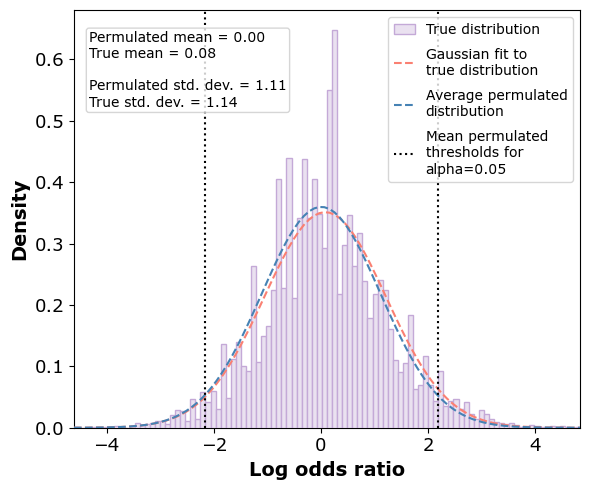

In [6]:
%autoreload 2
ortplot.plot_permulation_results(
    results,
    "duplication",
    fg_name="orbweavers",
    bg_name="non-orbweavers",
    gaussfit_color="salmon",
    avpermulation_color="steelblue",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    thresholds_color="black",
    title=False,
    legend_fontsize=10,
    textbox_fontsize=10,
    axis_label_fontsize=14
)

# plt.savefig(str(figure5 + "dup_results.png"), dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig(str(ort_results + "Run2_Dup_RT_50-max_10000x/dup_occ50-98_greater_permutation_results.png"), dpi=300, bbox_inches="tight")

## Loss permuted stats, all clades included

(<Figure size 650x500 with 1 Axes>,
 array([<Axes: xlabel='Means', ylabel='Count'>], dtype=object))

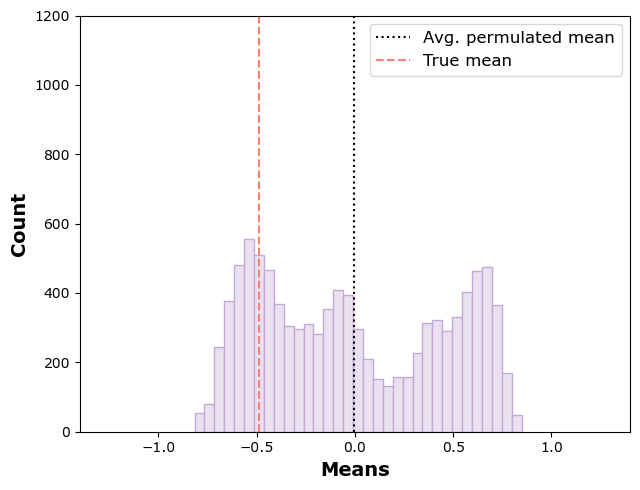

In [7]:
%autoreload 2
ortplot.plot_permulation_stats(
    results,
    "loss",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    ylim=(0, 1200),
    xlim=(-1.4, 1.4),
    binwidth=0.05
    
 )

# plt.savefig(str(figure5 + "/loss_all_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

## Duplication permuted stats, all clades included

(<Figure size 650x500 with 1 Axes>,
 array([<Axes: xlabel='Means', ylabel='Count'>], dtype=object))

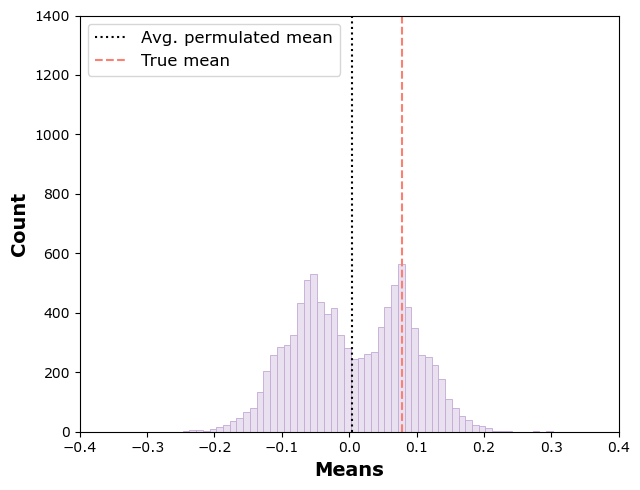

In [8]:

%autoreload 2
ortplot.plot_permulation_stats(
    results,
    "duplication",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    ylim=(0, 1400),
    xlim=(-0.4, 0.4),
    binwidth=0.01
 )

# plt.savefig(str(figure5 + "/dup_all_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

In [9]:
for label, arr in [("loss", results.means_loss), ("dup", results.means_dup)]:
    values, counts = np.unique(arr, return_counts=True)
    dupe_group_counts = counts[counts > 1]
    print(f"{label}: unique means = {len(values)} of {len(arr)}")
    print(f"{label}: duplicate mean groups = {len(dupe_group_counts)}")
    print(f"{label}: entries in duplicate mean groups = {int(dupe_group_counts.sum())}")
    if len(dupe_group_counts):
        print(f"{label}: largest duplicate group size = {int(dupe_group_counts.max())}")
    print()

loss: unique means = 9782 of 10000
loss: duplicate mean groups = 104
loss: entries in duplicate mean groups = 322
loss: largest duplicate group size = 40

dup: unique means = 9782 of 10000
dup: duplicate mean groups = 104
dup: entries in duplicate mean groups = 322
dup: largest duplicate group size = 40



## Loss permuted stats, no araneids


(<Figure size 650x500 with 1 Axes>,
 array([<Axes: xlabel='Means', ylabel='Count'>], dtype=object))

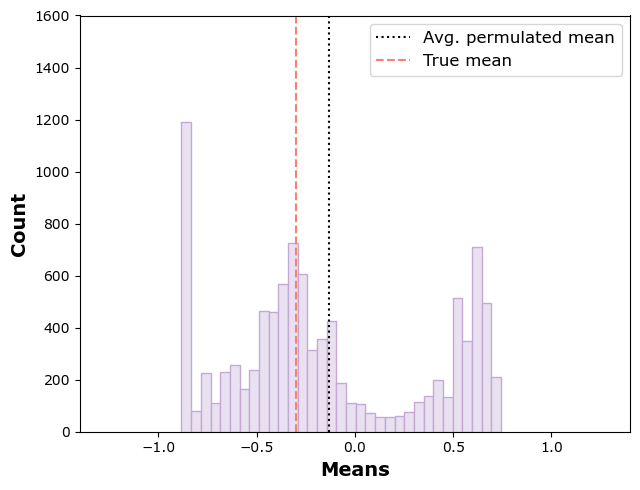

In [10]:
%autoreload 2
ort_dir = os.path.join(repo_root, "results/odds_ratio_test/Results_Apr14/Run2_occ_30-65_10000x_no_ara")

no_ara_results = ort.PermulationTestResults.load_from_pickle(f'{ort_dir}/results.pkl')

ortplot.plot_permulation_stats(
    no_ara_results,
    "loss",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    ylim=(0, 1600),
    xlim=(-1.4, 1.4),
 )

# plt.savefig(str(figure5 + "/loss_no_ara_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

In this run with no Araneids, there is one permulated tree that appears many times.

In [11]:
for label, arr in [("loss", no_ara_results.means_loss), ("dup", no_ara_results.means_dup)]:
    values, counts = np.unique(arr, return_counts=True)
    dupe_group_counts = counts[counts > 1]
    print(f"{label}: unique means = {len(values)} of {len(arr)}")
    print(f"{label}: duplicate mean groups = {len(dupe_group_counts)}")
    print(f"{label}: entries in duplicate mean groups = {int(dupe_group_counts.sum())}")
    if len(dupe_group_counts):
        print(f"{label}: largest duplicate group size = {int(dupe_group_counts.max())}")
    print()

loss: unique means = 5464 of 10000
loss: duplicate mean groups = 662
loss: entries in duplicate mean groups = 5198
loss: largest duplicate group size = 1174

dup: unique means = 5464 of 10000
dup: duplicate mean groups = 662
dup: entries in duplicate mean groups = 5198
dup: largest duplicate group size = 1174



This was also true in a previous run, using the same species, which generated a non-identical permulation tip values csv.

In [12]:
ort_dir = os.path.join(repo_root, "results/odds_ratio_test/Results_Apr13/Run2_occ_30-65_10000x")

no_ara_results_other_permulation = ort.PermulationTestResults.load_from_pickle(f'{ort_dir}/results.pkl')

for label, arr in [("loss", no_ara_results_other_permulation.means_loss), ("dup", no_ara_results_other_permulation.means_dup)]:
    values, counts = np.unique(arr, return_counts=True)
    dupe_group_counts = counts[counts > 1]
    print(f"{label}: unique means = {len(values)} of {len(arr)}")
    print(f"{label}: duplicate mean groups = {len(dupe_group_counts)}")
    print(f"{label}: entries in duplicate mean groups = {int(dupe_group_counts.sum())}")
    if len(dupe_group_counts):
        print(f"{label}: largest duplicate group size = {int(dupe_group_counts.max())}")
    print()

loss: unique means = 5403 of 10000
loss: duplicate mean groups = 727
loss: entries in duplicate mean groups = 5324
loss: largest duplicate group size = 1139

dup: unique means = 5403 of 10000
dup: duplicate mean groups = 727
dup: entries in duplicate mean groups = 5324
dup: largest duplicate group size = 1139



## Duplication permuted stats, no araneids


/Users/calvin/orb-selection/scripts/04_permulation_loss_dup/odds_ratio_test_plotting.py:506: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(<Figure size 650x650 with 2 Axes>,
 array([<Axes: xlabel='Means', ylabel='Count'>], dtype=object))

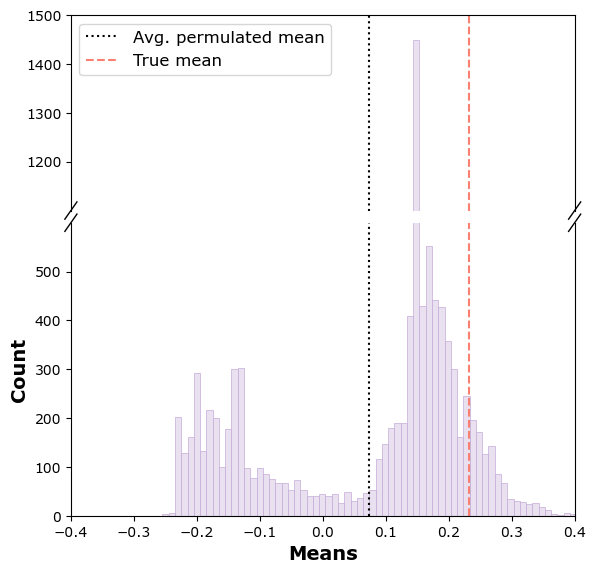

In [13]:
ortplot.plot_permulation_stats(
    no_ara_results,
    "duplication",
    hist_color="#EAE1F0",
    # hist_color="black",
    edgecolor="#C4A9D7",
    # edgecolor="black",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    split_y_axis=True,
    split_y_lims=((0, 600), (1100, 1500)),
    split_y_height_ratios="auto",
    xlim=(-0.4, 0.4),
    # binwidth=0.002
 )

# plt.savefig(str(figure5 + "/dup_no_ara_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

## Loss permuted stats, no tetragnathids

(<Figure size 650x500 with 1 Axes>,
 array([<Axes: xlabel='Means', ylabel='Count'>], dtype=object))

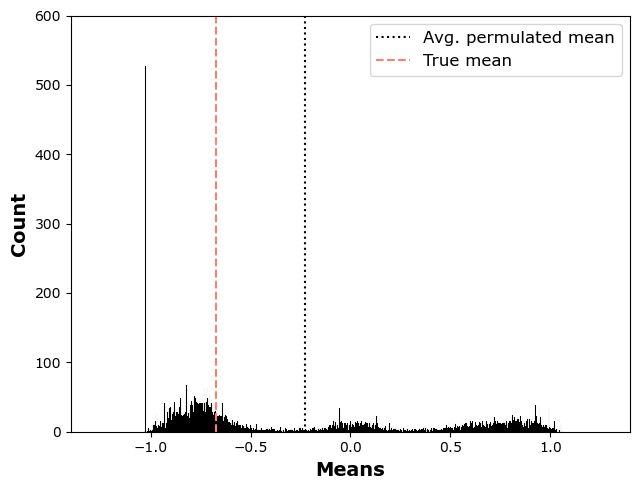

In [14]:
%autoreload 2
ort_dir = os.path.join(repo_root, "results/odds_ratio_test/Results_Apr14/Run3_occ_30-81_10000x_no_tet")

no_tet_results = ort.PermulationTestResults.load_from_pickle(f'{ort_dir}/results.pkl')
ortplot.plot_permulation_stats(
    no_tet_results,
    "loss",
    # hist_color="#EAE1F0",
    # edgecolor="#C4A9D7",
    hist_color="black",
    edgecolor="black",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    ylim=(0, 600),
    xlim=(-1.4, 1.4),
    binwidth=0.0025
 )

# plt.savefig(str(figure5 + "/loss_no_tet_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

## Duplication permuted stats, no tetragnathids

(<Figure size 650x500 with 1 Axes>,
 array([<Axes: xlabel='Means', ylabel='Count'>], dtype=object))

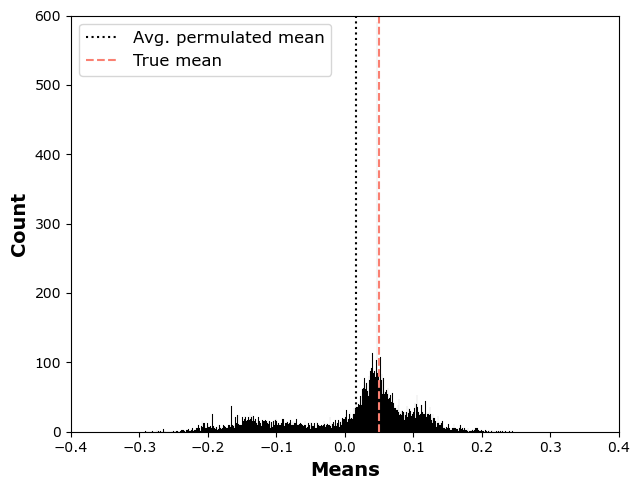

In [15]:
ortplot.plot_permulation_stats(
    no_tet_results,
    "duplication",
    # hist_color="#EAE1F0",
    # edgecolor="#C4A9D7",
    hist_color="black",
    edgecolor="black",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    ylim=(0, 600),
    xlim=(-0.4, 0.4),
    binwidth=0.0009
 )

# plt.savefig(str(figure5 + "/dup_no_tet_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

In [16]:
import numpy as np

for label, arr in [("loss", no_tet_results.means_loss), ("dup", no_tet_results.means_dup)]:
    values, counts = np.unique(arr, return_counts=True)
    dupe_group_counts = counts[counts > 1]
    print(f"{label}: unique means = {len(values)} of {len(arr)}")
    print(f"{label}: duplicate mean groups = {len(dupe_group_counts)}")
    print(f"{label}: entries in duplicate mean groups = {int(dupe_group_counts.sum())}")
    if len(dupe_group_counts):
        print(f"{label}: largest duplicate group size = {int(dupe_group_counts.max())}")
    print()

loss: unique means = 8462 of 10000
loss: duplicate mean groups = 455
loss: entries in duplicate mean groups = 1993
loss: largest duplicate group size = 526

dup: unique means = 8462 of 10000
dup: duplicate mean groups = 455
dup: entries in duplicate mean groups = 1993
dup: largest duplicate group size = 526

